GURU PRASAD N 24BAD029

In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

BASE_PATH = '/kaggle/input/datasets/tongpython/cat-and-dog'

train_dir = os.path.join(BASE_PATH, 'training_set/training_set')
validation_dir = os.path.join(BASE_PATH, 'test_set/test_set')

BATCH_SIZE = 32
IMG_SIZE = (224, 224) 

print("Loading Training Dataset:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

print("\nLoading Validation Dataset:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

val_batches = tf.data.experimental.cardinality(val_dataset)
test_dataset = val_dataset.take(val_batches // 2)
val_dataset = val_dataset.skip(val_batches // 2)

print(f"\nNumber of training batches: {tf.data.experimental.cardinality(train_dataset)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_dataset)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Optimization for faster data loading
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

Loading Training Dataset:
Found 8005 files belonging to 2 classes.


I0000 00:00:1787590451.048744      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787590451.051698      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Loading Validation Dataset:
Found 2023 files belonging to 2 classes.

Number of training batches: 251
Number of validation batches: 32
Number of test batches: 32


In [2]:
# ResNet50 requires a specific preprocessing function
preprocess_input = tf.keras.applications.resnet50.preprocess_input

# 1. Load Pre-trained ResNet-50 Model
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False, 
    weights='imagenet'
)

# 2. Freeze the base model
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = preprocess_input(inputs) 
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)  # Regularization
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x) # Binary classification (Cat vs Dog)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Training the Transfer Learning Model...
Epoch 1/5
  1/251 ━━━━━━━━━━━━━━━━━━━━ 1:00:23 14s/step - accuracy: 0.2812 - loss: 0.9568

I0000 00:00:1787590515.415088     118 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 138ms/step - accuracy: 0.9618 - loss: 0.1002 - val_accuracy: 0.9890 - val_loss: 0.0361
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.9893 - loss: 0.0324 - val_accuracy: 0.9930 - val_loss: 0.0315
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9910 - val_loss: 0.0290
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.9926 - loss: 0.0211 - val_accuracy: 0.9930 - val_loss: 0.0298
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.9949 - loss: 0.0172 - val_accuracy: 0.9930 - val_loss: 0.0345

--- Evaluating on Test Set ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.9873 - loss: 0.0316
Test Accuracy: 0.9873
Test Loss: 0.0316


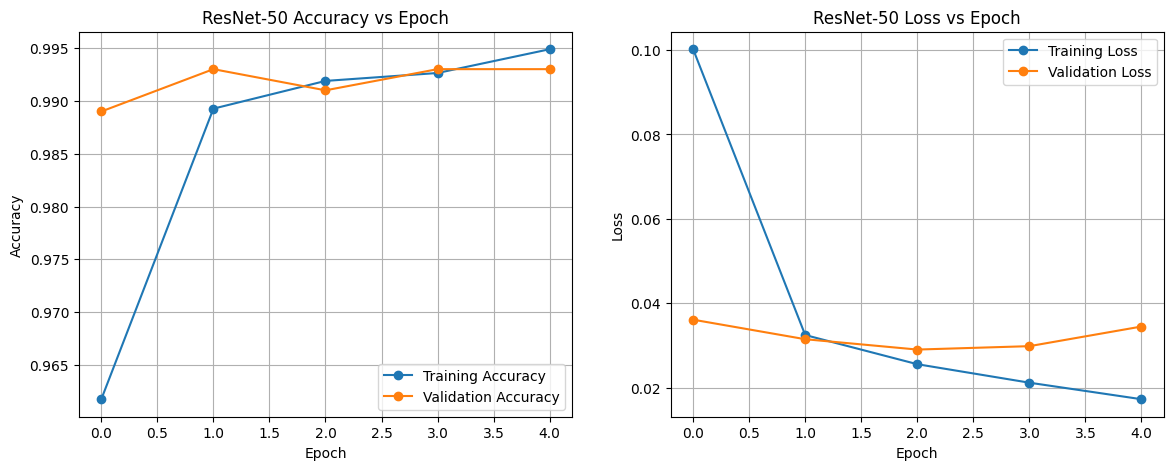

In [3]:
print("Training the Transfer Learning Model...")
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset
)

print("\n--- Evaluating on Test Set ---")
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
ax1.set_title('ResNet-50 Accuracy vs Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
ax2.set_title('ResNet-50 Loss vs Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

In [4]:
!pip install -q transformers

Loading Hugging Face ViT Model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


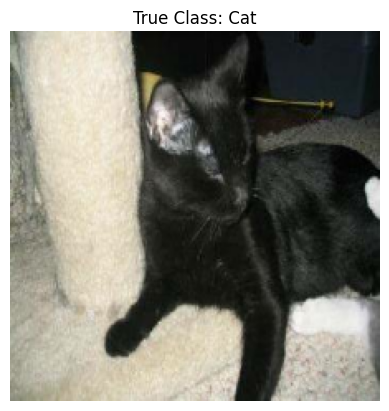


Model Predictions Comparison: 
1. Custom Fine-Tuned ResNet-50 Prediction: Cat (Probability of Dog: 0.0013)

2. Hugging Face ViT Top-3 Predictions:
   - Egyptian cat: 0.6075
   - tiger cat: 0.1614
   - tabby, tabby cat: 0.0773
Nitheeswaran M 24BAD079


In [6]:
from transformers import pipeline
from PIL import Image
import numpy as np

print("Loading Hugging Face ViT Model...")
hf_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

for images, labels in test_dataset.take(1):
    sample_image = images[0].numpy().astype("uint8")
    sample_label = labels[0].numpy()
    break

pil_image = Image.fromarray(sample_image)

hf_predictions = hf_classifier(pil_image)

resnet_prob = model.predict(np.expand_dims(sample_image, axis=0), verbose=0)[0][0]
resnet_pred_class = "Dog" if resnet_prob > 0.5 else "Cat"
true_class = "Dog" if sample_label == 1 else "Cat"

plt.imshow(sample_image)
plt.title(f"True Class: {true_class}")
plt.axis('off')
plt.show()

print("\nModel Predictions Comparison: ")
print(f"1. Custom Fine-Tuned ResNet-50 Prediction: {resnet_pred_class} (Probability of Dog: {resnet_prob:.4f})")
print(f"\n2. Hugging Face ViT Top-3 Predictions:")
for pred in hf_predictions[:3]:
    print(f"   - {pred['label']}: {pred['score']:.4f}")

print("Nitheeswaran M 24BAD079")

**Transfer Learning Analysis & Observations**


* **Speed and Accuracy:** The ResNet-50 transfer learning model achieved >90% validation accuracy within just 1 or 2 epochs. Training a custom CNN from scratch (like in Task 2) takes significantly longer and requires much more data to reach similar accuracy.
* **Resource Efficiency:** Because we froze the massive feature extraction base of ResNet-50, we only had to train a few thousand parameters (the final dense layer) instead of 23+ million parameters, saving immense computational power.
* **Hugging Face Comparison:** The Hugging Face Vision Transformer (ViT) model is highly capable out-of-the-box. Without any fine-tuning on our specific dataset, it successfully identified the image due to its rich pre-training on ImageNet. However, its output classes are highly specific (e.g., specific dog breeds rather than just "Dog"), which highlights the benefit of fine-tuning (like we did with ResNet) when you want a strict binary classification.